In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score
from datetime import datetime
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore') 

In [ ]:
df=pd.read_csv(r'D:\Python\ML\Projects\Logistic\Stock Prediction\stock.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100323,469033600
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.095089,175884800
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.088110,105728000
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090291,86441600
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092908,73449600


In [3]:
df['Date']=pd.to_datetime(df['Date'])

In [4]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [5]:
df['Year']=df['Date'].dt.year
df['Day']=df['Date'].dt.day
df['Month']=df['Date'].dt.month

In [6]:
df.dtypes

Date         datetime64[us]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                int64
Year                  int32
Day                   int32
Month                 int32
dtype: object

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10409 entries, 0 to 10408
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       10409 non-null  datetime64[us]
 1   Open       10409 non-null  float64       
 2   High       10409 non-null  float64       
 3   Low        10409 non-null  float64       
 4   Close      10409 non-null  float64       
 5   Adj Close  10409 non-null  float64       
 6   Volume     10409 non-null  int64         
 7   Year       10409 non-null  int32         
 8   Day        10409 non-null  int32         
 9   Month      10409 non-null  int32         
dtypes: datetime64[us](1), float64(5), int32(3), int64(1)
memory usage: 691.4 KB


In [8]:
df[['Open','High','Low','Close','Adj Close','Volume']].describe()

,Open,High,Low,Close,Adj Close,Volume
count,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,1.040900e+04
mean,13.959910,14.111936,13.809163,13.966757,13.350337,3.321778e+08
std,30.169244,30.514878,29.835055,30.191696,29.911132,3.393344e+08
min,0.049665,0.049665,0.049107,0.049107,0.038384,0.000000e+00
25%,0.281964,0.287946,0.274554,0.281250,0.234799,1.247604e+08
50%,0.468750,0.477679,0.459821,0.468750,0.386853,2.199680e+08
75%,14.217857,14.364286,14.043571,14.206071,12.188149,4.126108e+08
max,182.630005,182.940002,179.119995,182.009995,181.778397,7.421641e+09


In [9]:
df.drop(columns='Date',inplace=True)

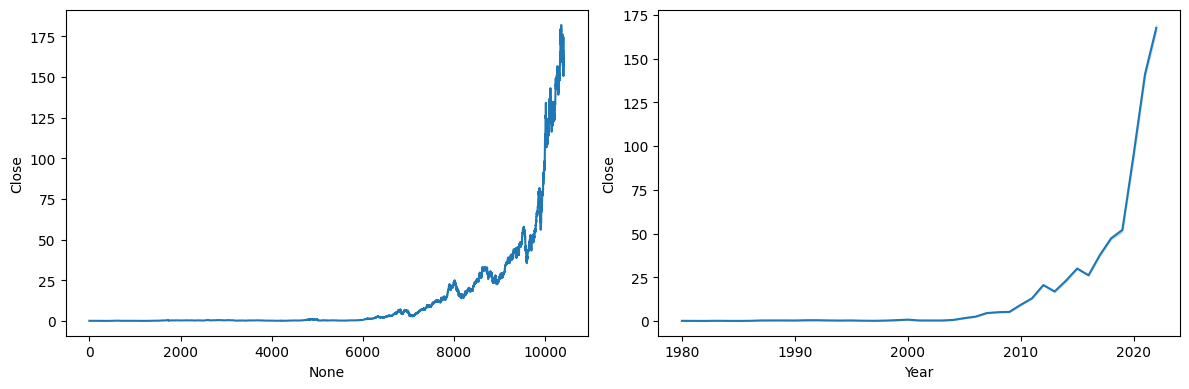

In [10]:
fig,ax=plt.subplots(1,2,figsize=(12,4))
sns.lineplot(data=df,x=df.index,y='Close',ax=ax[0])
sns.lineplot(data=df,x='Year',y='Close',ax=ax[1])
plt.tight_layout()
plt.show()

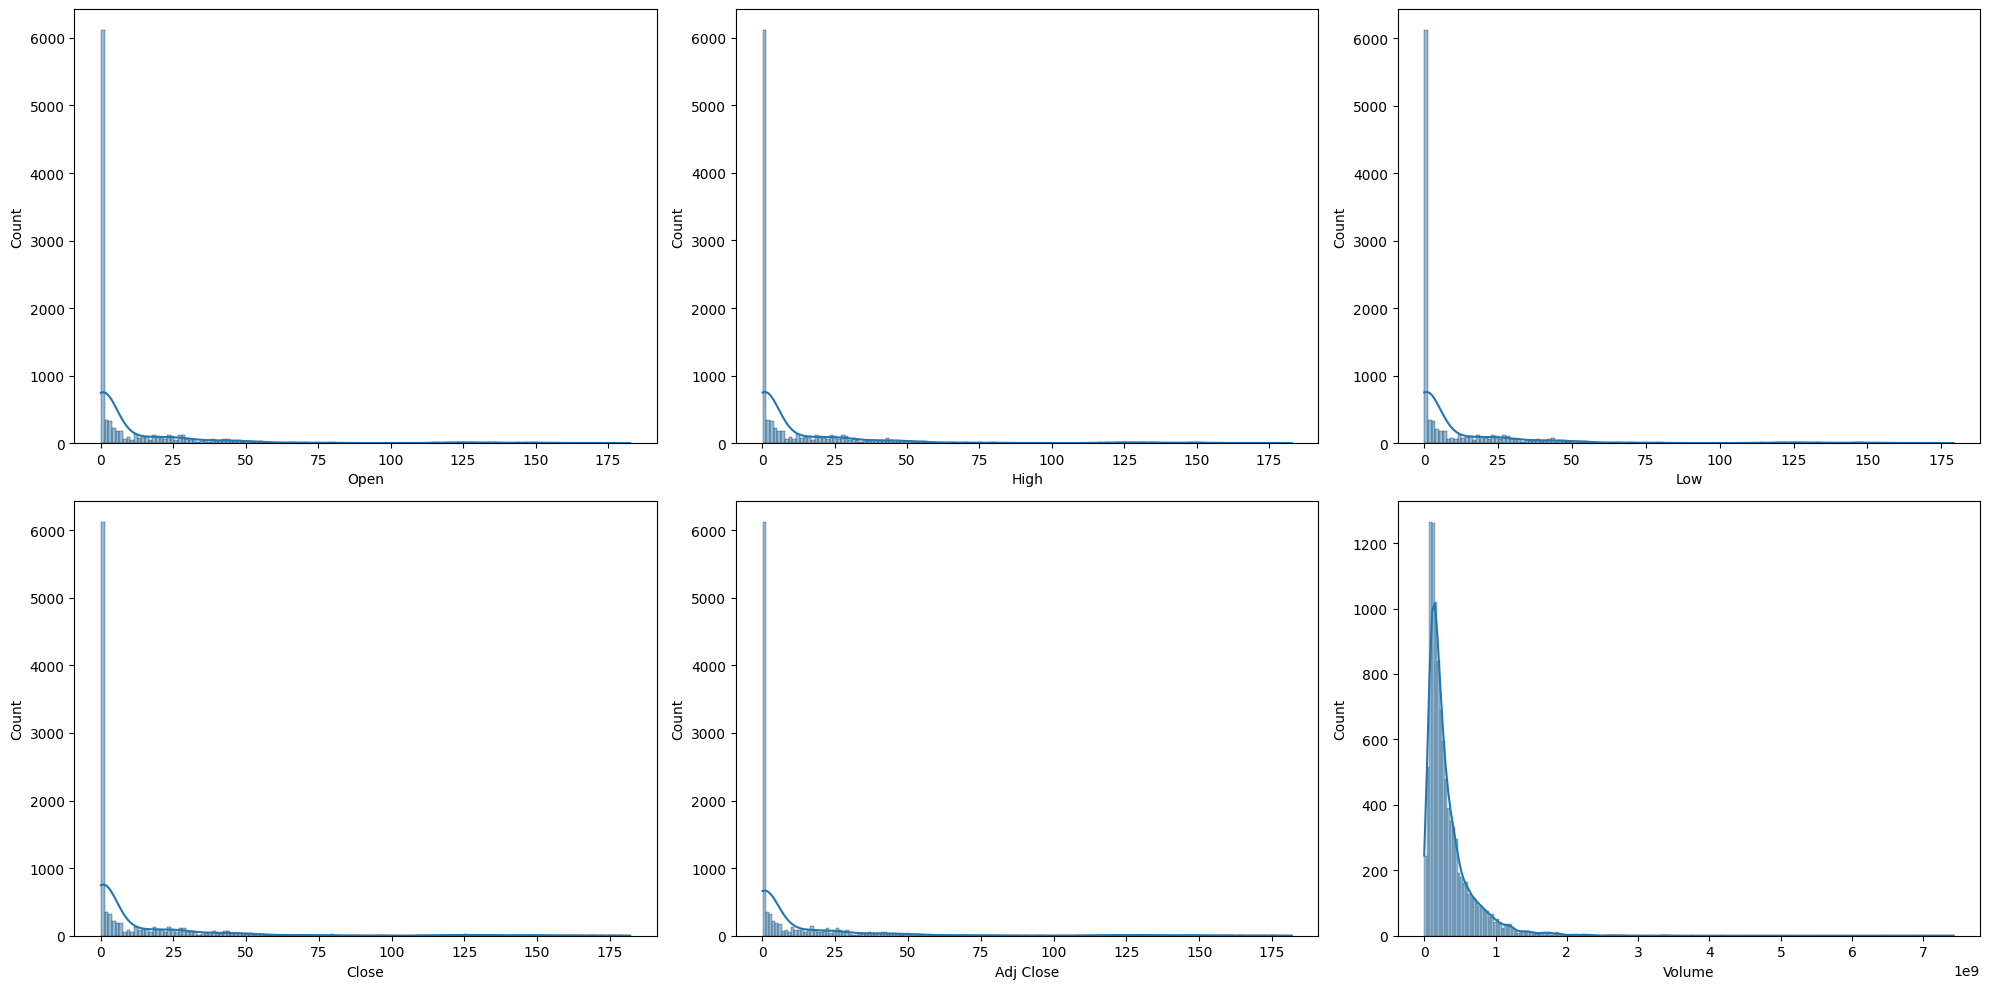

In [11]:
features=['Open','High','Low','Close','Adj Close', 'Volume']
fig,ax=plt.subplots(2,3,figsize=(20,10))
for i,col in enumerate(features):
    sns.histplot(df[col],kde=True,ax=ax.flat[i])
plt.tight_layout()
plt.show()

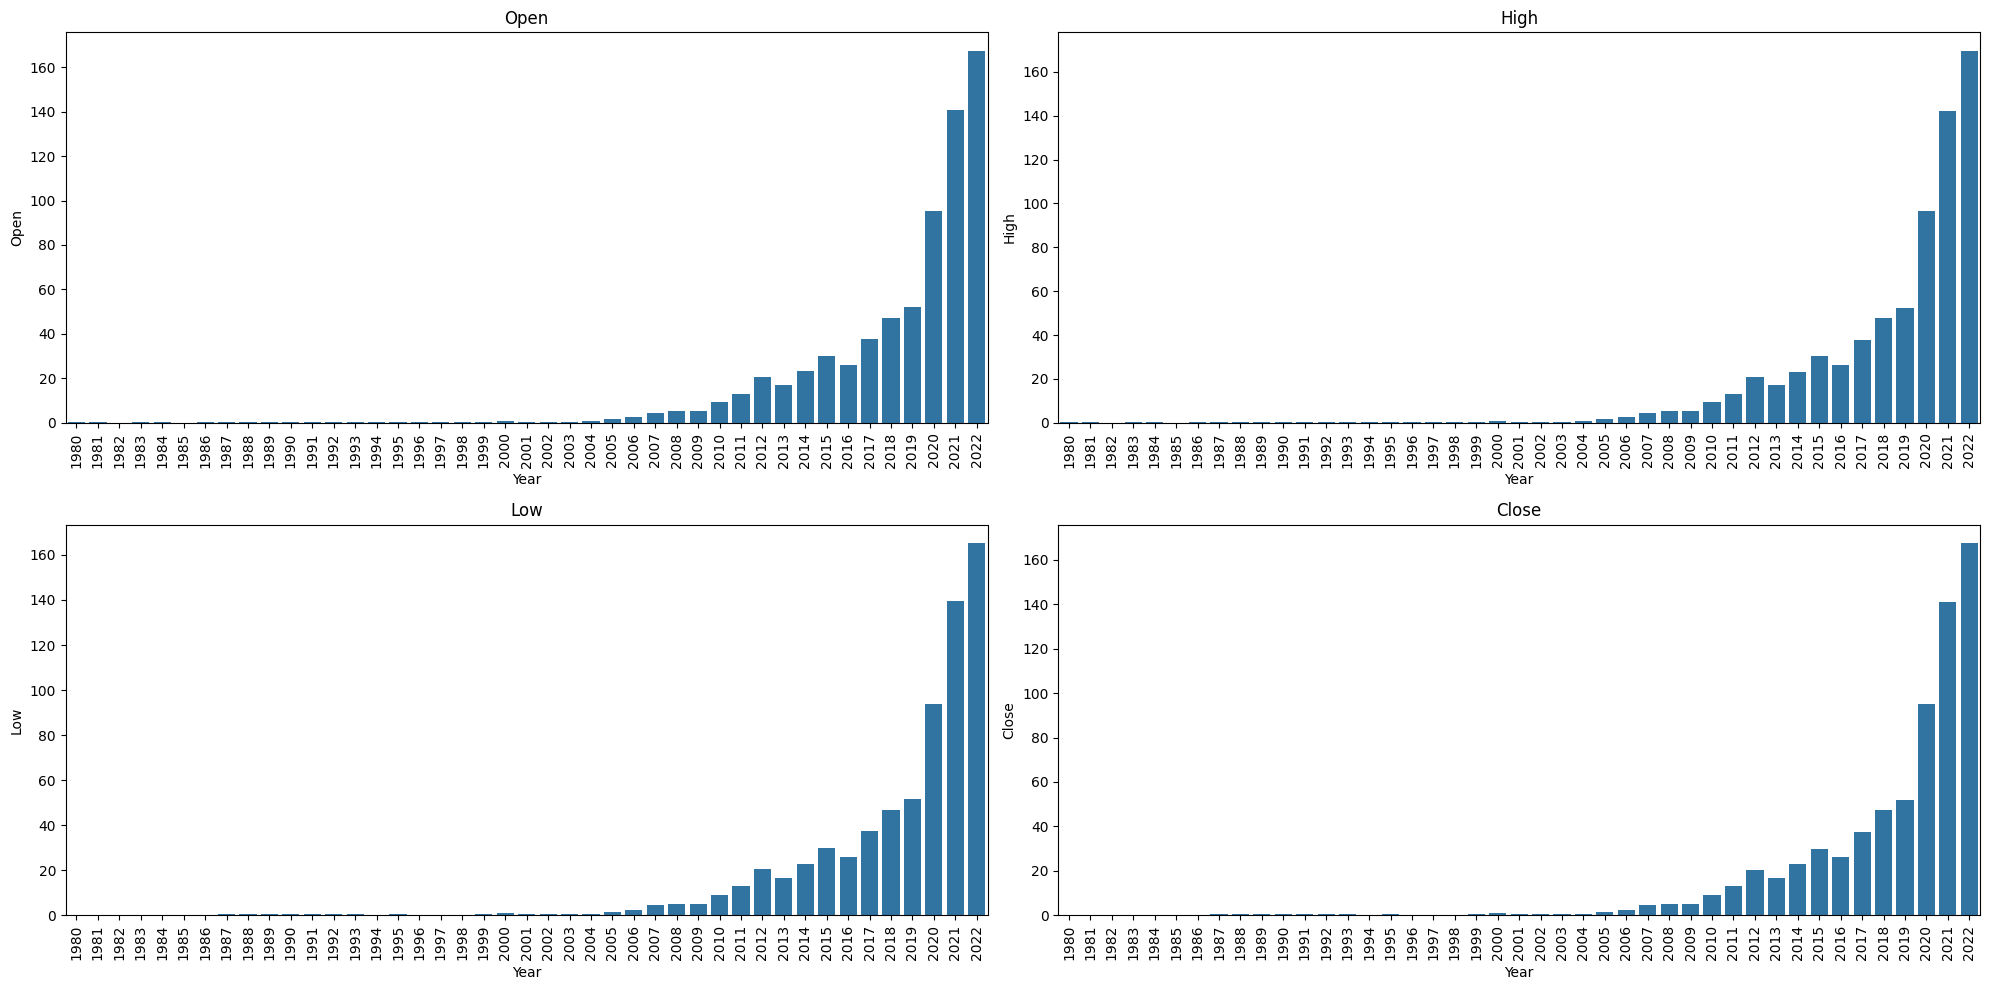

In [12]:
df_group = df.groupby('Year').mean(numeric_only=True)
fig, ax = plt.subplots(2, 2, figsize=(20, 10))
for i, col in enumerate(['Open', 'High', 'Low', 'Close']):
    sns.barplot(x=df_group.index,y=df_group[col],ax=ax.flat[i])
    ax.flat[i].set_title(col)
    ax.flat[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

In [13]:
df['Qtr_end']=np.where(df['Month']%3==0,1,0)

In [14]:
df.groupby('Qtr_end').mean()

,Open,High,Low,Close,Adj Close,Volume,Year,Day,Month
Qtr_end,,,,,,,,,
0,13.823884,13.971968,13.681730,13.835594,13.216806,3.412706e+08,2001.095335,15.727036,6.055201
1,14.227618,14.387401,14.059961,14.224895,13.613133,3.142828e+08,2001.013972,15.755632,7.434559


<Axes: xlabel='Qtr_end', ylabel='Close'>

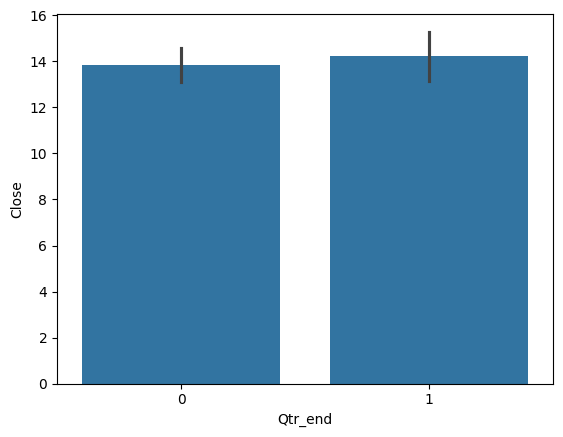

In [15]:
sns.barplot(df,x='Qtr_end',y='Close')

In [16]:
df['open_close']=df['Open']-df['Close']
df['low_high']=df['Low']-df['High']
df['Target']=np.where(df['Close'].shift(-1)>df['Close'],1,0)

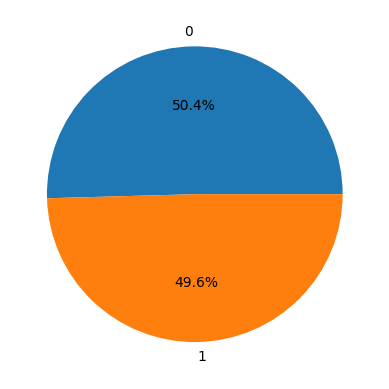

In [17]:
plt.pie(df['Target'].value_counts().values,labels=[0,1],autopct='%1.1f%%')
plt.show()

In [18]:
X=df[['open_close','low_high','Qtr_end']]
y=df['Target']
scaler=StandardScaler()

In [19]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
X_train.shape

(8327, 3)

In [21]:
models=[LogisticRegression(),SVC(kernel='poly',probability=True),XGBClassifier()]
for model in models:
    model.fit(X_train,y_train)
    x_pred=model.predict(X_train)
    y_pred=model.predict(X_test)
    print(f"\n{model}")
    print(f"Train Accuracy : {accuracy_score(y_train,x_pred)}")
    print(f"Test Accuracy : {accuracy_score(y_test,y_pred)}")


LogisticRegression()
Train Accuracy : 0.5204755614266843
Test Accuracy : 0.49279538904899134

SVC(kernel='poly', probability=True)
Train Accuracy : 0.5142308154197189
Test Accuracy : 0.4769452449567723

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)
Train Accuracy : 0.7164645130299028